In [22]:
from collections import Counter

def count_severity_table(data: dict):
    """
    data: dict like {
        "microsoft.com": {"moicrosoft.com": 1, ...},
        "libertymutual.com": {...},
        ...
    }
    """
    counts = Counter()

    for original_domain, typos in data.items():
        for transformed_domain, severity in typos.items():
            counts[severity] += 1

    # Ensure keys 1,2,3 exist
    for sev in (1, 2, 3):
        counts.setdefault(sev, 0)

    # Print as a simple table
    print("| Severity | Count |")
    print("|----------|-------|")
    for sev in (1, 2, 3):
        print(f"| {sev:<8} | {counts[sev]:<5} |")

    return counts


In [23]:
import json

with open("./disputes-training.json", "r") as f:
    data = json.load(f)

count_severity_table(data)


| Severity | Count |
|----------|-------|
| 1        | 506   |
| 2        | 80    |
| 3        | 5     |


Counter({1: 506, 2: 80, 3: 5})

In [24]:
def average_severity_per_domain(data: dict):
    """
    data: dict like
    {
        "microsoft.com": {"moicrosoft.com": 1, "microspft.com": 2, ...},
        "libertymutual.com": {"libetrymutual.com": 1, "ilbertymutual.com": 2, ...},
        ...
    }

    Returns: dict mapping original domain -> average severity (float)
    """
    averages = {}

    for original_domain, typos in data.items():
        if not typos:
            averages[original_domain] = 0.0
            continue

        total = 0
        count = 0
        for _, severity in typos.items():
            total += severity
            count += 1

        averages[original_domain] = total / count

    return averages


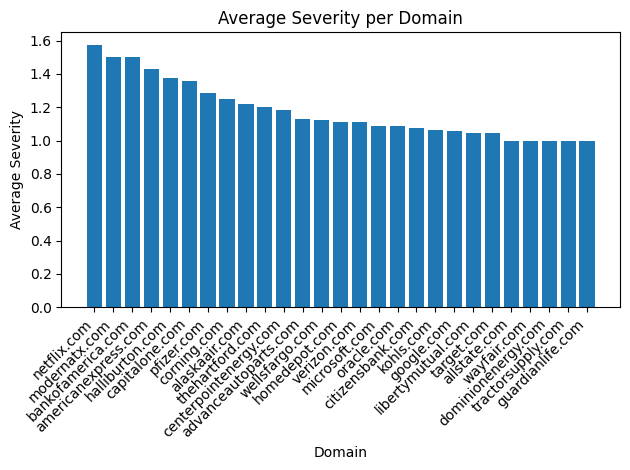

In [25]:
# Average severity per domain bar chart

import matplotlib.pyplot as plt

averages = average_severity_per_domain(data)
ranked = sorted(averages.items(), key=lambda x: x[1], reverse=True)

domains = [d for d, _ in ranked]
avg_scores = [s for _, s in ranked]

plt.figure()
plt.bar(domains, avg_scores)
plt.xlabel("Domain")
plt.ylabel("Average Severity")
plt.title("Average Severity per Domain")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [26]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_disputes_by_severity_sorted(data: dict):
    """
    data format:
    {
        "microsoft.com": {"moicrosoft.com": 1, "microsof.com": 2, ...},
        "libertymutual.com": {...},
        ...
    }

    For each domain:
      - counts how many 1, 2, 3 severities it has
      - sorts domains by TOTAL disputes (descending)
      - shows a stacked bar chart with different colors for 1/2/3

    Returns: dict[domain] = {"severity_1": n1, "severity_2": n2, "severity_3": n3, "total": total}
    """
    rows = []

    # Count severities per domain
    for domain, typos in data.items():
        c = Counter(typos.values())
        n1 = c.get(1, 0)
        n2 = c.get(2, 0)
        n3 = c.get(3, 0)
        total = n1 + n2 + n3
        rows.append((domain, n1, n2, n3, total))

    # Sort by total descending
    rows.sort(key=lambda r: r[4], reverse=True)

    # Unpack sorted rows
    domains   = [r[0] for r in rows]
    counts_1  = [r[1] for r in rows]
    counts_2  = [r[2] for r in rows]
    counts_3  = [r[3] for r in rows]

    details = {
        d: {"severity_1": n1, "severity_2": n2, "severity_3": n3, "total": tot}
        for d, n1, n2, n3, tot in rows
    }

    x = range(len(domains))

    plt.figure()
    # stacked bars: severity 1 at bottom, then 2, then 3
    plt.bar(x, counts_1, label="Severity 1")  # color 1
    plt.bar(x, counts_2, bottom=counts_1, label="Severity 2")  # color 2
    bottom_12 = [a + b for a, b in zip(counts_1, counts_2)]
    plt.bar(x, counts_3, bottom=bottom_12, label="Severity 3")  # color 3

    plt.xticks(x, domains, rotation=45, ha="right")
    plt.xlabel("Domain")
    plt.ylabel("Number of disputes")
    plt.title("Disputes per domain by severity (sorted by total)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return details


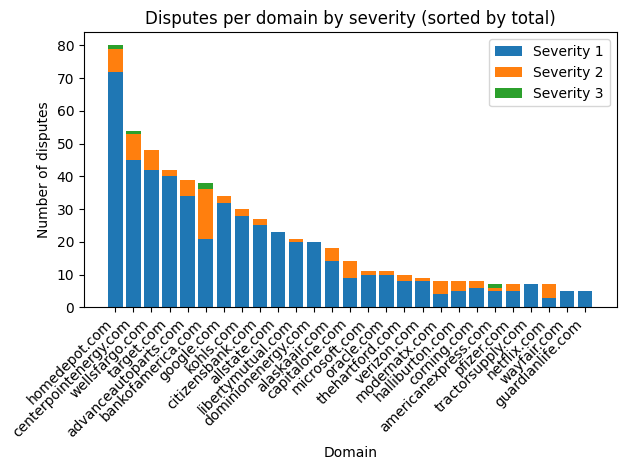

{'homedepot.com': {'severity_1': 72, 'severity_2': 7, 'severity_3': 1, 'total': 80}, 'centerpointenergy.com': {'severity_1': 45, 'severity_2': 8, 'severity_3': 1, 'total': 54}, 'wellsfargo.com': {'severity_1': 42, 'severity_2': 6, 'severity_3': 0, 'total': 48}, 'target.com': {'severity_1': 40, 'severity_2': 2, 'severity_3': 0, 'total': 42}, 'advanceautoparts.com': {'severity_1': 34, 'severity_2': 5, 'severity_3': 0, 'total': 39}, 'bankofamerica.com': {'severity_1': 21, 'severity_2': 15, 'severity_3': 2, 'total': 38}, 'google.com': {'severity_1': 32, 'severity_2': 2, 'severity_3': 0, 'total': 34}, 'kohls.com': {'severity_1': 28, 'severity_2': 2, 'severity_3': 0, 'total': 30}, 'citizensbank.com': {'severity_1': 25, 'severity_2': 2, 'severity_3': 0, 'total': 27}, 'allstate.com': {'severity_1': 23, 'severity_2': 0, 'severity_3': 0, 'total': 23}, 'libertymutual.com': {'severity_1': 20, 'severity_2': 1, 'severity_3': 0, 'total': 21}, 'dominionenergy.com': {'severity_1': 20, 'severity_2': 0, 

In [27]:
details = plot_disputes_by_severity_sorted(data)
print(details)
